# 05 HEST-1k high-confidence HE-to-ST symbol95

这个 notebook 记录正式大基因集版本的 HE-to-ST 实验。基因集固定为：**high-confidence train slides 中 coverage >= 95% 的 canonical gene symbol**。

本 notebook 不重新训练模型；它读取已经训练和评估得到的 checkpoint / metrics，并重新执行轻量 audit 与单张 slide 的空间叠图。


## 本轮固定规则

- 只用 train split 选择 gene，避免 test leakage。
- gene key 优先使用 `.h5ad.var["SYMBOL"]`；没有 `SYMBOL` 时使用 `var_names`。
- 不使用 `Unspecified_gene_id` 这类无效 gene id。
- coverage 阈值固定为 `slides_present / n_train_slides >= 0.95`。
- 某张 slide 缺失某个 gene 时，用 `expression_mask` 跳过该 gene 的 loss 和 metric。


In [1]:

from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import DataLoader

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src" / "histoomnist").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root containing src/histoomnist.")
os.chdir(ROOT)
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from histoomnist.data.dataset import ExpressionRateDataset, FeatureStandardizer
from histoomnist.data.gene_selection import load_gene_keys_for_slide, selected_genes_from_config
from histoomnist.data.spot_table import load_spot_table
from histoomnist.eval.evaluate_combined import _load_rate_model, _load_sf_model
from histoomnist.train.common import load_checkpoint
from histoomnist.utils.config import get_device_name, load_config
from histoomnist.utils.io import read_manifest

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.dpi"] = 130


In [2]:

paths = {
    "manifest": ROOT / "data/HEST-1k/manifests/human_visium_sf_manifest_highconf_context.csv",
    "genes": ROOT / "data/HEST-1k/manifests/highconf_symbol_coverage95_genes.txt",
    "gene_report": ROOT / "results/hest1k_human_visium_expression/highconf_symbol_coverage95_gene_selection.csv",
    "sf_config": ROOT / "configs/hest1k_human_visium_sf_context_distribution_light.yaml",
    "sf_checkpoint": ROOT / "checkpoints/hest1k_human_visium_sf/context_distribution_light_hipt256_leave_slide_out/best.pt",
    "expression_config": ROOT / "configs/hest1k_human_visium_expression_highconf_symbol95.yaml",
    "expression_checkpoint": ROOT / "checkpoints/hest1k_human_visium_expression/highconf_symbol95_rate/best.pt",
    "metrics_json": ROOT / "results/hest1k_human_visium_expression/highconf_symbol95_combined_test_metrics.json",
}
existence = pd.DataFrame(
    [{"name": key, "path": str(path.relative_to(ROOT)), "exists": path.exists()} for key, path in paths.items()]
)
display(existence)
assert existence["exists"].all(), "有必要文件不存在，请先完成前置步骤。"


,name,path,exists
0,manifest,data\HEST-1k\manifests\human_visium_sf_manifes...,True
1,genes,data\HEST-1k\manifests\highconf_symbol_coverag...,True
2,gene_report,results\hest1k_human_visium_expression\highcon...,True
3,sf_config,configs\hest1k_human_visium_sf_context_distrib...,True
4,sf_checkpoint,checkpoints\hest1k_human_visium_sf\context_dis...,True
5,expression_config,configs\hest1k_human_visium_expression_highcon...,True
6,expression_checkpoint,checkpoints\hest1k_human_visium_expression\hig...,True
7,metrics_json,results\hest1k_human_visium_expression\highcon...,True


In [3]:

manifest = pd.read_csv(paths["manifest"])
genes = paths["genes"].read_text(encoding="utf-8").splitlines()
gene_report = pd.read_csv(paths["gene_report"])

print(f"High-confidence slides: {manifest.shape[0]}")
print(f"Train slides used for gene selection: {(manifest['split'] == 'train').sum()}")
print(f"Coverage95 genes: {len(genes)}")
print(f"Minimum slides present in report: {gene_report['slides_present'].min()}")
display(gene_report.head(20))


High-confidence slides: 234
Train slides used for gene selection: 163
Coverage95 genes: 16942
Minimum slides present in report: 155


,gene,slides_present,slide_fraction,measured_spots,total_count,mean_count,detected_spots,detected_fraction,detected_fraction_measured
0,HSPB1,163,1.0,381781,4463996.0,11.692557,300806,0.787902,0.787902
1,CTSD,163,1.0,381781,3157220.0,8.269715,296637,0.776982,0.776982
2,APP,163,1.0,381781,3081358.0,8.071009,274754,0.719664,0.719664
3,SQSTM1,163,1.0,381781,4022172.0,10.535286,271810,0.711953,0.711953
4,RHOA,163,1.0,381781,2262605.0,5.926447,266923,0.699152,0.699152
5,TPM1,163,1.0,381781,3833775.0,10.041817,261989,0.686228,0.686228
6,MIF,163,1.0,381781,2995262.0,7.845498,235999,0.618153,0.618153
7,PGAM1,163,1.0,381781,903448.0,2.366404,229419,0.600918,0.600918
8,APOE,163,1.0,381781,2515726.0,6.589448,225869,0.591619,0.591619
9,CYCS,163,1.0,381781,1130243.0,2.960449,225713,0.591211,0.591211


In [4]:

base = paths["manifest"].parent
gene_set = set(genes)
audit_rows = []
for row in manifest.itertuples(index=False):
    keys = load_gene_keys_for_slide(
        sample_id=str(row.sample_id),
        processed_gene_path=base / str(row.genes_path),
        gene_key="symbol",
        raw_st_root=ROOT / "data/HEST-1k/raw/st",
    )
    present = {key for key in keys if key is not None}
    n_present = len(gene_set & present)
    audit_rows.append(
        {
            "sample_id": row.sample_id,
            "split": row.split,
            "organ": row.organ,
            "present_symbol95_genes": n_present,
            "fraction": n_present / len(genes),
        }
    )
audit = pd.DataFrame(audit_rows)
display(audit.groupby("split")["present_symbol95_genes"].describe())
display(audit.groupby(["split", "organ"])["present_symbol95_genes"].agg(["count", "min", "median", "max"]))
print(f"Slides with zero target genes: {(audit['present_symbol95_genes'] == 0).sum()}")
display(audit[(audit["split"] == "test") & (audit["organ"] == "Heart")])


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,48.0,16255.520833,3203.160633,971.0,16923.5,16942.0,16942.0,16942.0
train,163.0,16726.699387,1749.247161,1080.0,16941.5,16942.0,16942.0,16942.0
val,23.0,16915.956522,60.823499,16689.0,16942.0,16942.0,16942.0,16942.0


count    min   median    max
split organ                               
test  Bowel      15  16426  16919.0  16942
      Brain       9   1149  16942.0  16942
      Breast      1    971    971.0    971
      Eye         1  16866  16866.0  16866
      Heart       9  16938  16942.0  16942
      Skin       13  16942  16942.0  16942
train Bowel      51   1080  16928.0  16942
      Brain      29   1111  16942.0  16942
      Breast      6  16919  16942.0  16942
      Eye         4  16866  16866.0  16942
      Heart      29  16938  16942.0  16942
      Skin       44  16942  16942.0  16942
val   Bowel       7  16689  16874.0  16942
      Brain       4  16942  16942.0  16942
      Breast      1  16942  16942.0  16942
      Eye         1  16866  16866.0  16866
      Heart       4  16942  16942.0  16942
      Skin        6  16942  16942.0  16942

Slides with zero target genes: 0


,sample_id,split,organ,present_symbol95_genes,fraction
131,MISC102,test,Heart,16942,1.000000
143,MISC114,test,Heart,16942,1.000000
146,MISC117,test,Heart,16942,1.000000
148,MISC119,test,Heart,16942,1.000000
153,MISC124,test,Heart,16942,1.000000
154,MISC125,test,Heart,16942,1.000000
155,MISC126,test,Heart,16942,1.000000
158,MISC129,test,Heart,16938,0.999764
159,MISC130,test,Heart,16938,0.999764


## Combined test metrics

下面这些指标来自已经实际运行的 combined evaluation：

```text
scripts/evaluate_combined.py
```

它把 coverage95 rate model 接到当前固定 SF predictor 上，比较不乘 SF、乘预测 SF、乘真实 SF 上限的 count-scale 预测。


In [5]:

metrics = json.loads(paths["metrics_json"].read_text(encoding="utf-8"))
metric_rows = [
    ("SF", "log_sf_pearson", metrics["sf_log_sf_pearson"], "预测 log(SF) 和真实 log(SF) 的相关性"),
    ("SF", "sf_std_ratio", metrics["sf_sf_std_ratio"], "预测 SF 波动幅度 / 真实 SF 波动幅度"),
    ("SF", "sf_top_decile_mean_ratio", metrics["sf_sf_top_decile_mean_ratio"], "真实最高 10% SF 区域的尾部恢复程度"),
    ("Rate", "rate_mean_gene_pearson", metrics["rate_mean_gene_pearson"], "16,942 个 gene 的逐基因相关性平均值"),
    ("Rate", "rate_median_gene_pearson", metrics["rate_median_gene_pearson"], "16,942 个 gene 的逐基因相关性中位数"),
    ("Count", "count_no_sf_mean_gene_pearson", metrics["count_no_sf_mean_gene_pearson"], "只用预测 rate，不乘 SF"),
    ("Count", "count_pred_sf_mean_gene_pearson", metrics["count_pred_sf_mean_gene_pearson"], "预测 rate × 预测 SF"),
    ("Count", "count_oracle_sf_mean_gene_pearson", metrics["count_oracle_sf_mean_gene_pearson"], "预测 rate × 真实 SF，上限分析"),
]
metric_table = pd.DataFrame(metric_rows, columns=["group", "metric", "value", "meaning"])
display(metric_table)


,group,metric,value,meaning
0,SF,log_sf_pearson,0.785951,预测 log(SF) 和真实 log(SF) 的相关性
1,SF,sf_std_ratio,0.825083,预测 SF 波动幅度 / 真实 SF 波动幅度
2,SF,sf_top_decile_mean_ratio,0.723400,真实最高 10% SF 区域的尾部恢复程度
3,Rate,rate_mean_gene_pearson,0.158303,"16,942 个 gene 的逐基因相关性平均值"
4,Rate,rate_median_gene_pearson,0.126752,"16,942 个 gene 的逐基因相关性中位数"
5,Count,count_no_sf_mean_gene_pearson,0.327788,只用预测 rate，不乘 SF
6,Count,count_pred_sf_mean_gene_pearson,0.352898,预测 rate × 预测 SF
7,Count,count_oracle_sf_mean_gene_pearson,0.397610,预测 rate × 真实 SF，上限分析


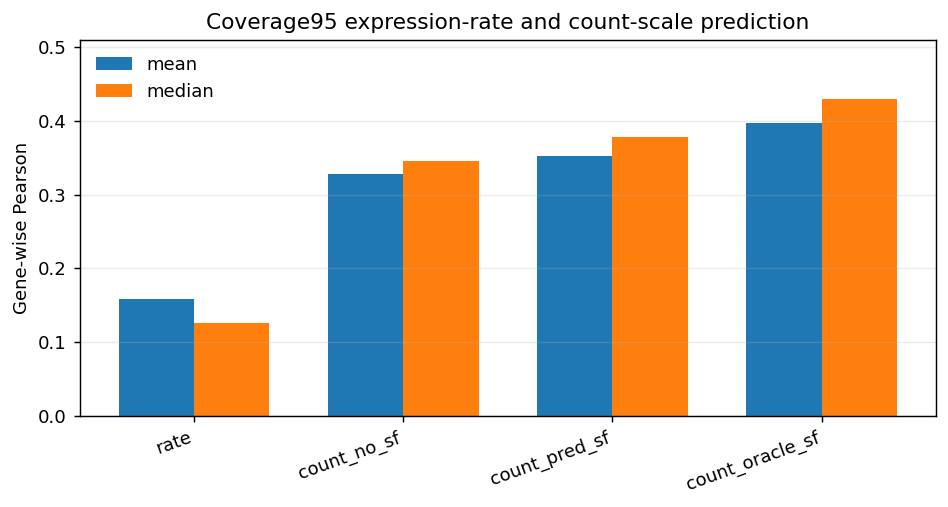

,setting,mean_gene_pearson,median_gene_pearson
0,rate,0.158303,0.126752
1,count_no_sf,0.327788,0.345392
2,count_pred_sf,0.352898,0.377954
3,count_oracle_sf,0.397610,0.429754


In [6]:

plot_df = pd.DataFrame(
    {
        "setting": ["rate", "count_no_sf", "count_pred_sf", "count_oracle_sf"],
        "mean_gene_pearson": [
            metrics["rate_mean_gene_pearson"],
            metrics["count_no_sf_mean_gene_pearson"],
            metrics["count_pred_sf_mean_gene_pearson"],
            metrics["count_oracle_sf_mean_gene_pearson"],
        ],
        "median_gene_pearson": [
            metrics["rate_median_gene_pearson"],
            metrics["count_no_sf_median_gene_pearson"],
            metrics["count_pred_sf_median_gene_pearson"],
            metrics["count_oracle_sf_median_gene_pearson"],
        ],
    }
)
fig, ax = plt.subplots(figsize=(7.4, 4.0))
x = np.arange(len(plot_df))
width = 0.36
ax.bar(x - width / 2, plot_df["mean_gene_pearson"], width, label="mean")
ax.bar(x + width / 2, plot_df["median_gene_pearson"], width, label="median")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["setting"], rotation=20, ha="right")
ax.set_ylabel("Gene-wise Pearson")
ax.set_ylim(0, max(plot_df["median_gene_pearson"].max(), plot_df["mean_gene_pearson"].max()) + 0.08)
ax.legend(frameon=False)
ax.set_title("Coverage95 expression-rate and count-scale prediction")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()
display(plot_df)


## 空间 QC

下面只对一张 test slide 生成空间叠图。目的是检查预测结果能否叠回组织切片坐标，而不是重新计算全数据集指标。


In [7]:

def predict_one_slide(sample_id: str, gene: str):
    sf_config = load_config(paths["sf_config"])
    expr_config = load_config(paths["expression_config"])
    device = torch.device(get_device_name(expr_config.get("device")))
    sf_ckpt = load_checkpoint(paths["sf_checkpoint"], map_location=str(device))
    rate_ckpt = load_checkpoint(paths["expression_checkpoint"], map_location=str(device))
    manifest_df = read_manifest(paths["manifest"])
    one = manifest_df[manifest_df["sample_id"] == sample_id].copy()
    gene_names, gene_indices = selected_genes_from_config(expr_config, base_dir=paths["manifest"].parent)
    ds = ExpressionRateDataset(
        one,
        base_dir=paths["manifest"].parent,
        splits=["test"],
        min_total_counts=float(expr_config["data"].get("min_total_counts", 1.0)),
        standardizer=FeatureStandardizer(mean=rate_ckpt["feature_mean"], std=rate_ckpt["feature_std"]),
        gene_names=gene_names,
        gene_indices=gene_indices,
        gene_key="symbol",
        raw_st_root=ROOT / "data/HEST-1k/raw/st",
    )
    gene_idx = gene_names.index(gene)
    rate_model = _load_rate_model(expr_config, rate_ckpt, device)
    sf_model = _load_sf_model(sf_config, sf_ckpt, device)
    sf_standardizer = FeatureStandardizer(mean=sf_ckpt["feature_mean"], std=sf_ckpt["feature_std"])
    loader = DataLoader(ds, batch_size=int(expr_config["training"]["batch_size"]), shuffle=False)
    pred_sf, true_sf, pred_rate_gene, true_rate_gene, measured = [], [], [], [], []
    with torch.no_grad():
        for batch in loader:
            pred_log1p_rate = rate_model(batch["features"].to(device)).cpu().numpy()
            pred_rate_gene.append(np.expm1(pred_log1p_rate[:, gene_idx]).clip(min=0.0))
            true_rate_gene.append(np.expm1(batch["log1p_rate"].numpy()[:, gene_idx]))
            measured.append(batch["expression_mask"].numpy()[:, gene_idx].astype(bool))
            raw = batch["raw_features"].numpy()
            sf_features = sf_standardizer.transform(raw)
            pred_log_sf = sf_model(torch.from_numpy(sf_features).to(device)).cpu().numpy().reshape(-1)
            pred_sf.append(np.exp(pred_log_sf))
            true_sf.append(np.exp(batch["true_log_sf"].numpy().reshape(-1)))
    pred_sf = np.concatenate(pred_sf)
    pred_sf = pred_sf / (pred_sf.mean() + 1e-8)
    true_sf = np.concatenate(true_sf)
    pred_rate_gene = np.concatenate(pred_rate_gene)
    true_rate_gene = np.concatenate(true_rate_gene)
    measured = np.concatenate(measured)
    return {
        "dataset": ds,
        "gene": gene,
        "pred_sf": pred_sf,
        "true_sf": true_sf,
        "pred_count_gene": pred_rate_gene * pred_sf,
        "true_count_gene": true_rate_gene * true_sf,
        "measured": measured,
    }


sample_id = "MISC33"
gene = "HSPB1"
pred = predict_one_slide(sample_id, gene)
print(f"{sample_id} spots: {len(pred['dataset'])}; measured {gene}: {pred['measured'].sum()}")


MISC33 spots: 3385; measured HSPB1: 3385


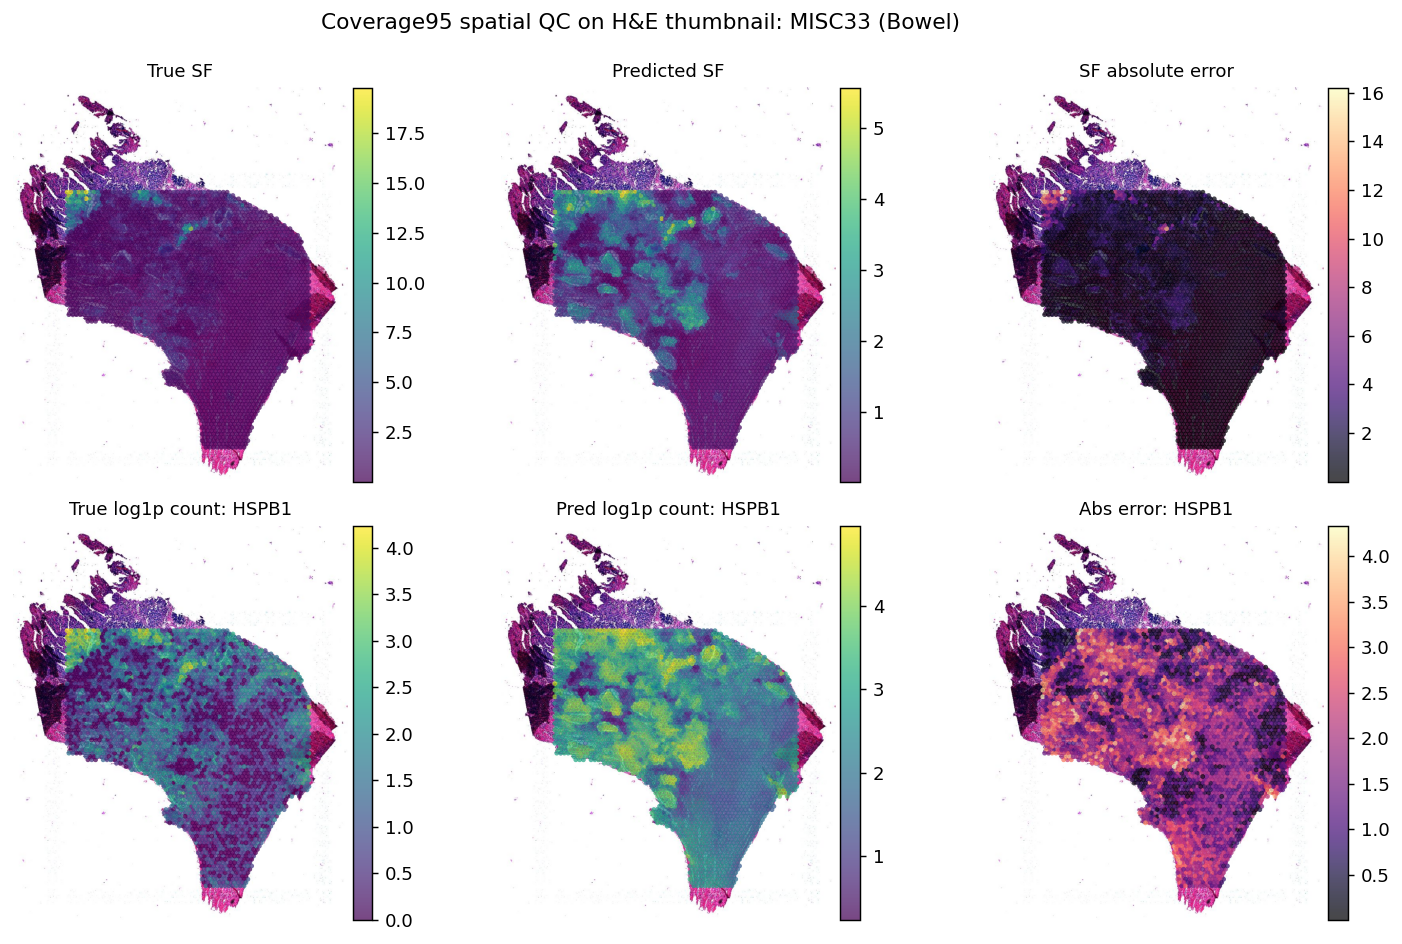

results\hest1k_human_visium_expression\highconf_symbol95_spatial_overlay_MISC33_HSPB1.png


In [8]:

def coords_for_sample(sample_id: str):
    manifest_df = read_manifest(paths["manifest"])
    row = manifest_df.loc[manifest_df["sample_id"] == sample_id].iloc[0]
    table = load_spot_table(
        sample_id=sample_id,
        features_path=paths["manifest"].parent / str(row["features_path"]),
        counts_path=paths["manifest"].parent / str(row["counts_path"]),
        coords_path=paths["manifest"].parent / str(row["coords_path"]),
        size_factor_path=paths["manifest"].parent / str(row["size_factor_path"]),
        min_total_counts=1.0,
    )
    return table.coords[table.valid_mask]


coords = coords_for_sample(sample_id)
keep = pred["measured"]
meta_path = ROOT / "data/HEST-1k/processed" / sample_id / "metadata.json"
meta = json.loads(meta_path.read_text(encoding="utf-8"))
thumb_path = ROOT / "data/HEST-1k/raw/thumbnails" / f"{sample_id}_downscaled_fullres.jpeg"
img = plt.imread(thumb_path)
img_h, img_w = img.shape[:2]
xy = np.column_stack(
    [
        coords[keep, 0] / float(meta["fullres_px_width"]) * img_w,
        coords[keep, 1] / float(meta["fullres_px_height"]) * img_h,
    ]
)

panels = [
    (pred["true_sf"][keep], "True SF", "viridis"),
    (pred["pred_sf"][keep], "Predicted SF", "viridis"),
    (np.abs(pred["pred_sf"][keep] - pred["true_sf"][keep]), "SF absolute error", "magma"),
    (np.log1p(pred["true_count_gene"][keep]), f"True log1p count: {gene}", "viridis"),
    (np.log1p(pred["pred_count_gene"][keep]), f"Pred log1p count: {gene}", "viridis"),
    (
        np.abs(np.log1p(pred["pred_count_gene"][keep]) - np.log1p(pred["true_count_gene"][keep])),
        f"Abs error: {gene}",
        "magma",
    ),
]
fig, axes = plt.subplots(2, 3, figsize=(12, 7.2))
for ax, (values, title, cmap) in zip(axes.ravel(), panels):
    ax.imshow(img)
    sc = ax.scatter(xy[:, 0], xy[:, 1], c=values, s=7, cmap=cmap, alpha=0.72, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()
    fig.colorbar(sc, ax=ax, fraction=0.040, pad=0.01)
fig.suptitle(f"Coverage95 spatial QC on H&E thumbnail: {sample_id} ({meta.get('organ', '')})", y=0.99)
fig.tight_layout()
out_fig = ROOT / "results/hest1k_human_visium_expression" / f"highconf_symbol95_spatial_overlay_{sample_id}_{gene}.png"
out_fig.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_fig, bbox_inches="tight")
plt.show()
print(out_fig.relative_to(ROOT))


## 当前结论

coverage95 大基因集已经替代 top256 成为正式表达预测设置。当前结果显示，预测 SF 仍然能提升 count-scale prediction，但大基因集的 gene-wise rate correlation 明显低于 top256，说明后续重点应该转向 per-gene / per-organ 诊断和表达模型结构升级。
